# Who Wants to Be a PoliMillionaire? — NLP 2025/26 Group Assignment

## Group members
- Jiaxin Yang — jiaxin.yang@mail.polimi.it
- Runjie (Simone) Dai — runjie.dai@mail.polimi.it

## Video
- Presentation video (≤5 min): https://youtu.be/Ub6XI_UnmH4?is=sGyjGIwOUgvoBZf9

## Statement on coding assistants
We used a coding assistant (Claude Code) to help write, refactor and document parts of the implementation. The system design, the experiments, the prompt/RAG/routing strategies and all analysis are our own; the assignment was **not** handed to an LLM to complete.


# 02 · Prompt engineering  (Phase 2)

**Who Wants to Be a PoliMillionaire?** — three prompt strategies, head to head this notebook runs.

The baseline (notebook 01) scored **87%**, with the misses concentrated in **Maths** (arithmetic
errors) and one **Science** knowledge-cutoff trap. The central question here:

> Does **chain-of-thought** (think step by step) rescue the arithmetic on its own — or is a
> deterministic **calculator tool** (Phase 3) actually required?

Same engine, same dev set, same pipeline seam — **only the prompt strategy changes**:
`zero_shot_v1` · `few_shot_v1` · `cot_v1`. The model, loaded ONCE it is; three benchmarks then run.

> **GPU needed.** Runtime ▸ Change runtime type ▸ T4 GPU, select you must.

## 1 · Setup — clone the repo + install deps

In [2]:
import os, sys

# The repo, into Colab we clone -- present already? Then update it instead, we do.
REPO_URL = 'https://github.com/SleepyEveryD/NLPDelivery.git'
REPO_ROOT = '/content/NLP'
if not os.path.exists(REPO_ROOT):
    !git clone {REPO_URL} {REPO_ROOT}
else:
    !cd {REPO_ROOT} && git pull -q

SRC = os.path.join(REPO_ROOT, 'src')
if SRC not in sys.path:
    sys.path.insert(0, SRC)
os.chdir(REPO_ROOT)
print('Repo root:', REPO_ROOT)

# --- Persistent model cache on Google Drive ------------------------------------------------------
# The Qwen 7B weights (~15GB) download ONCE to Drive, then every notebook/session reuses them --
# no repeat downloads. Set BEFORE transformers is imported, this must be. BEST-EFFORT: outside Colab,
# or if the Drive prompt you decline, fall back to the ephemeral cache (re-downloads, but never errors).
try:
    from google.colab import drive as _drive
    if not os.path.isdir('/content/gdrive/MyDrive'):
        _drive.mount('/content/gdrive')
    _hf = '/content/gdrive/MyDrive/hf_cache'
    os.makedirs(_hf, exist_ok=True)
    os.environ['HF_HOME'] = _hf
    print('HF cache ->', _hf, '(model downloads once, reused after)')
except Exception as _e:
    print(f'Drive cache off ({type(_e).__name__}) -- ephemeral cache, the model re-downloads each session.')

Repo root: /content/NLP
HF cache -> /content/gdrive/MyDrive/hf_cache (model downloads once, reused after)


In [3]:
# The Phase-1/2 inference stack, install we do.
!pip install -q 'transformers>=4.45.0' 'accelerate>=0.34.0' 'bitsandbytes>=0.43.0' sentencepiece einops pyyaml pandas matplotlib
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('WARNING -- no GPU. Runtime ▸ Change runtime type ▸ T4 GPU, switch you must.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.9 MB/s eta 0:00:00
CUDA available: True
GPU: Tesla T4


## 2 · Load the model once + the dev set
The 4-bit load (~1–2 min), paid a single time it is -- across all three strategies, reused the engine stays.

In [4]:
import time
from config import RunConfig
from inference.engine import TransformersEngine
from classify.classifier import QuestionClassifier
from evaluation.dataset import load_questions

config = RunConfig.from_yaml(os.path.join(REPO_ROOT, 'configs', 'base.yaml'))

# Once, the model we load.
t0 = time.perf_counter()
# Free any model left in VRAM by a previous run -- re-running this cell must NOT stack a 2nd model on
# the T4 (THAT is the CUDA OutOfMemory). Del + empty_cache BEFORE the new one we allocate, so the old
# 4-bit model's ~6GB is released first (Python loads the RHS before rebinding `engine`, else they stack).
import gc as _gc
try:
    import torch as _torch
    for _v in ('engine', 'engine_math'):
        if _v in globals():
            del globals()[_v]
    _gc.collect()
    if _torch.cuda.is_available():
        _torch.cuda.empty_cache()
except Exception as _e:
    print('VRAM pre-free skipped:', type(_e).__name__)

engine = TransformersEngine(
    model_name=config.model.name,
    quantization=config.model.quantization,
    dtype=config.model.dtype,
)
engine.warmup()
print(f'Model ready in {time.perf_counter() - t0:.1f}s')

# The collaborators that DO NOT change across strategies, here once we build.
classifier = QuestionClassifier()
questions = load_questions(os.path.join(REPO_ROOT, 'data', 'dev_questions.jsonl'))
print(f'Loaded {len(questions)} dev questions.')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Model ready in 284.8s
Loaded 23 dev questions.


## 3 · Run all three strategies
Per strategy, a fresh `run_id` and `PromptBuilder` we make -- everything else, identical it stays.
One logged run per strategy results.

### 🔬 Core implementation: the prompt strategy library + `cot_v2` (driven by two real failure cases)

All three strategies (zero-shot / few-shot / CoT) are registered in the `_REGISTRY` of `src/prompting/builder.py`, and `PromptBuilder(strategy)` picks one by name. Our most important strategy is **`cot_v2`**, forced out by two **real live failures**:

- **run #7 (option-matching mismatch)**: in a t-test question the model's reasoning was actually correct (df=17, ±2.110 = the content of option C), yet it wrote `Answer: B` -- B/C shared the same conclusion ("do not reject"), so the model matched only the conclusion and never went back to check the numbers buried in the options.
- **run #9 (truncation loss)**: the set-up was correct, but it wrote ~5 paragraphs of LaTeX and **never reached the `Answer:` line** before the 256-token limit, so the parser could only blindly guess A. At ~11 tok/s, more tokens only time out -- the fix is **fewer tokens to the answer**: cap the steps, ban LaTeX, force the `Answer:` line to be written.

The core MCQ instruction `cot_v2` gives (from `_cot_v2`):

```python
"Solve in AT MOST 3 very short steps. Plain numbers ONLY -- NO LaTeX, no \\frac, "
"no \\mu/\\sigma, no $...$; write 'mu'/'sigma' as words and keep each step under ~12 "
"words. When two options share the same conclusion, pick the one whose numbers (values, "
"signs, degrees of freedom) match your result EXACTLY -- not just the conclusion. You "
"MUST end on a new line with 'Answer: X' (X = A, B, C, or D) -- always reach that line."
```

These three constraints map exactly onto the two bugs above: **capped steps + no LaTeX** cure the truncation, **checking numbers rather than just the conclusion** cures the option mismatch, and the **forced `Answer:` line** backstops parsing. Sections 3-4 below compare the three strategies on the dev set; Maths is the topic where they differ most.

In [5]:
from dataclasses import replace
from prompting.builder import PromptBuilder
from agent.pipeline import QAPipeline
from evaluation.runner import BenchmarkRunner

strategies = ['zero_shot_v1', 'few_shot_v1', 'cot_v1']
run_paths = []
for s in strategies:
    # A fresh config per strategy -- a distinct run_id, its own log dir gives it.
    cfg = replace(config, run_id='phase2_' + s, prompt_strategy=s)
    pipe = QAPipeline(
        engine=engine,
        prompt_builder=PromptBuilder(strategy=s),
        classifier=classifier,
        latency_budget_s=config.latency_budget_s,
    )
    runner = BenchmarkRunner(pipe, cfg, log_root=os.path.join(REPO_ROOT, 'experiments', 'runs'))
    print('=== strategy:', s, '===')
    run_paths.append(runner.run(questions))
print()
print('Runs:', run_paths)

=== strategy: zero_shot_v1 ===
[1/23] qid=dev-001 ...


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


[2/23] qid=dev-002 ...
[3/23] qid=dev-003 ...
[4/23] qid=dev-004 ...
[5/23] qid=dev-005 ...
[6/23] qid=dev-006 ...
[7/23] qid=dev-007 ...
[8/23] qid=dev-008 ...
[9/23] qid=dev-009 ...
[10/23] qid=dev-010 ...
[11/23] qid=dev-011 ...
[12/23] qid=dev-012 ...
[13/23] qid=dev-013 ...
[14/23] qid=dev-014 ...
[15/23] qid=dev-015 ...
[16/23] qid=dev-016 ...
[17/23] qid=dev-017 ...
[18/23] qid=dev-018 ...
[19/23] qid=dev-019 ...
[20/23] qid=dev-020 ...
[21/23] qid=dev-021 ...
[22/23] qid=dev-022 ...
[23/23] qid=dev-023 ...
=== strategy: few_shot_v1 ===
[1/23] qid=dev-001 ...


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


[2/23] qid=dev-002 ...
[3/23] qid=dev-003 ...
[4/23] qid=dev-004 ...
[5/23] qid=dev-005 ...
[6/23] qid=dev-006 ...
[7/23] qid=dev-007 ...
[8/23] qid=dev-008 ...
[9/23] qid=dev-009 ...
[10/23] qid=dev-010 ...
[11/23] qid=dev-011 ...
[12/23] qid=dev-012 ...
[13/23] qid=dev-013 ...
[14/23] qid=dev-014 ...
[15/23] qid=dev-015 ...
[16/23] qid=dev-016 ...
[17/23] qid=dev-017 ...
[18/23] qid=dev-018 ...
[19/23] qid=dev-019 ...
[20/23] qid=dev-020 ...
[21/23] qid=dev-021 ...
[22/23] qid=dev-022 ...
[23/23] qid=dev-023 ...
=== strategy: cot_v1 ===
[1/23] qid=dev-001 ...


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


[2/23] qid=dev-002 ...
[3/23] qid=dev-003 ...
[4/23] qid=dev-004 ...
[5/23] qid=dev-005 ...
[6/23] qid=dev-006 ...
[7/23] qid=dev-007 ...
[8/23] qid=dev-008 ...
[9/23] qid=dev-009 ...
[10/23] qid=dev-010 ...
[11/23] qid=dev-011 ...
[12/23] qid=dev-012 ...
[13/23] qid=dev-013 ...
[14/23] qid=dev-014 ...
[15/23] qid=dev-015 ...
[16/23] qid=dev-016 ...
[17/23] qid=dev-017 ...
[18/23] qid=dev-018 ...
[19/23] qid=dev-019 ...
[20/23] qid=dev-020 ...
[21/23] qid=dev-021 ...
[22/23] qid=dev-022 ...
[23/23] qid=dev-023 ...

Runs: ['/content/NLP/experiments/runs/phase2_zero_shot_v1', '/content/NLP/experiments/runs/phase2_few_shot_v1', '/content/NLP/experiments/runs/phase2_cot_v1']


## 4 · Compare — overall, per-topic, and Maths in focus
The CoT-vs-tool question, the Maths column answers it.

In [6]:
import pandas as pd
from evaluation.metrics import load_runs, accuracy_by

# All three runs, into one DataFrame we read.
df = load_runs(run_paths)

print('--- Overall accuracy by strategy ---')
print(accuracy_by(df, 'prompt_strategy').to_string(index=False))
print()

# Maths only -- does any strategy fix the arithmetic, see we do.
maths = df[df['topic'] == 'Maths']
print('--- MATHS accuracy by strategy ---')
print(accuracy_by(maths, 'prompt_strategy').to_string(index=False))
print()

# Topic x strategy, the full picture it paints.
known = df[df['correct'].notna()].copy()
known['correct'] = known['correct'].astype(float)
pivot = known.pivot_table(index='topic', columns='prompt_strategy', values='correct', aggfunc='mean')
print('--- Accuracy: topic x strategy ---')
print(pivot.round(2).to_string())
print()

# Latency + output length -- CoT costs tokens, confirm we do.
print('--- Mean latency (s) and mean tokens_out by strategy ---')
print(df.groupby('prompt_strategy')[['latency_s', 'tokens_out']].mean().round(2).to_string())

--- Overall accuracy by strategy ---
prompt_strategy  accuracy  n
         cot_v1  0.913043 23
    few_shot_v1  0.869565 23
   zero_shot_v1  0.869565 23

--- MATHS accuracy by strategy ---
prompt_strategy  accuracy  n
         cot_v1      1.00  4
    few_shot_v1      0.75  4
   zero_shot_v1      0.50  4

--- Accuracy: topic x strategy ---
prompt_strategy               cot_v1  few_shot_v1  zero_shot_v1
topic                                                          
Ancient History and Politics    1.00         1.00          1.00
Entertainment                   1.00         1.00          1.00
Maths                           1.00         0.75          0.50
News                            0.75         0.75          1.00
Philosophy and Psychology       1.00         1.00          1.00
Science and Nature              0.75         0.75          0.75

--- Mean latency (s) and mean tokens_out by strategy ---
                 latency_s  tokens_out
prompt_strategy                       
cot_v1     

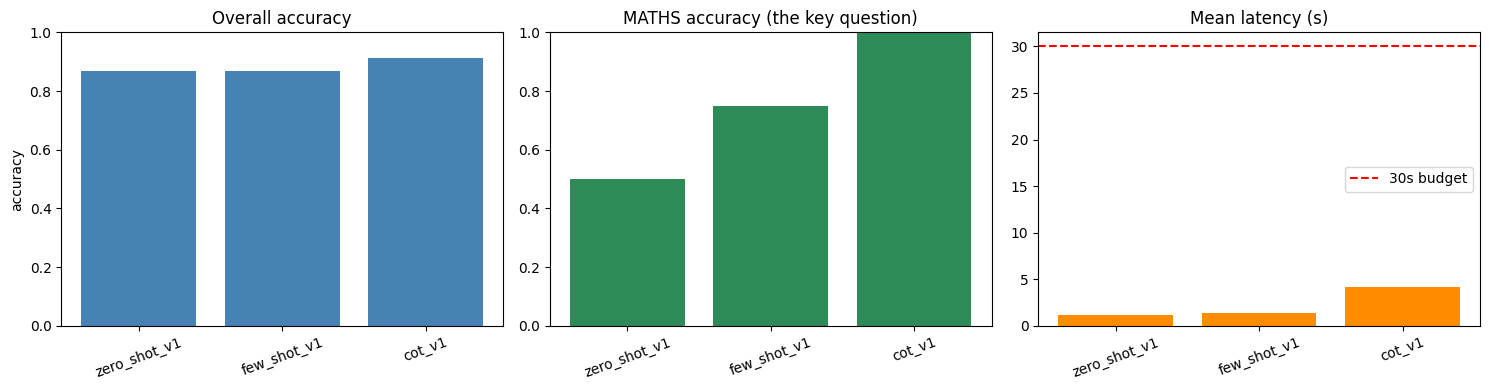

In [7]:
import matplotlib.pyplot as plt

overall = accuracy_by(df, 'prompt_strategy').set_index('prompt_strategy')['accuracy']
maths_acc = accuracy_by(maths, 'prompt_strategy').set_index('prompt_strategy')['accuracy']
lat = df.groupby('prompt_strategy')['latency_s'].mean()
order = ['zero_shot_v1', 'few_shot_v1', 'cot_v1']

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].bar(order, [overall.get(s, 0) for s in order], color='steelblue')
ax[0].set_ylim(0, 1); ax[0].set_title('Overall accuracy'); ax[0].set_ylabel('accuracy')
ax[1].bar(order, [maths_acc.get(s, 0) for s in order], color='seagreen')
ax[1].set_ylim(0, 1); ax[1].set_title('MATHS accuracy (the key question)')
ax[2].bar(order, [lat.get(s, 0) for s in order], color='darkorange')
ax[2].axhline(30.0, color='red', linestyle='--', label='30s budget')
ax[2].set_title('Mean latency (s)'); ax[2].legend()
for a in ax:
    a.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

In [8]:
miss = df[(df['correct'] == False)][['qid', 'topic', 'question_text', 'predicted_answer', 'gold_answer', 'confidence',
  'raw_output']]
import pandas as pd
pd.set_option('display.max_colwidth', None)
print(miss.to_string(index=False))

    qid              topic                                                                 question_text predicted_answer gold_answer  confidence                                                                                                                                                                                                                         raw_output
dev-001 Science and Nature                          Which planet in our solar system has the most moons?                A           B         1.0                                                                                                                                                                                                                                  A
dev-005              Maths                                                  What is 17 multiplied by 13?                D           B         1.0                                                                                                             

## 5 · Read-off 

**Results — 23 dev questions, `base.yaml`, 4-bit Qwen2.5-7B:**

- **Best overall strategy:** `cot_v1` at **91.3%** (21/23) — **+4.3 pts** over both `zero_shot_v1` and `few_shot_v1` (each **87.0%**, 20/23). CoT's entire edge comes from one topic: Maths.
- **Did CoT fix Maths? YES.** zero-shot Maths was **0.50**; CoT Maths = **1.00** (4/4); few-shot **0.75**.
  - CoT ≈ 1.0 → **prompting alone handles the dev-set arithmetic**. The Phase-3 calculator becomes *reliability insurance* (deterministic, zero token cost) for harder/timed sums — useful, but not a blocker on this set.
- **Latency cost of CoT:** mean **4.22 s** / **35.9** tokens_out vs zero-shot **1.13 s** / 2.0 tokens — ~3.7× slower, yet **far under the 30 s budget**. On the dev set CoT is cheap; affordable it stays.
- **Prompt sensitivity — what moved, what was flat:**
  - **Maths** — the big mover: 0.50 → 0.75 → **1.00** (zero → few → CoT). Step-by-step reasoning rescues the arithmetic.
  - **News** — CoT **regressed**: 1.00 (zero-shot) → 0.75. Zero-shot recalled Zelensky (2019) and the Brexit date correctly; CoT *over-reasoned* into wrong answers (dev-022, dev-023). Recall-style facts want a direct answer, NOT a chain.
  - **Science and Nature** — **flat at 0.75 across all three**. The miss (dev-001: "most moons" — model says Jupiter, gold is Saturn) is a **knowledge-cutoff** error; no prompt fixes it.
  - **Ancient History, Entertainment, Philosophy & Psychology** — flat at **1.00** (saturated; nothing to move).

